<a href="https://colab.research.google.com/github/raz0208/Natural-Language-Processing-Practices/blob/main/TopicModelling/EmbeddingsAnalysis_TopicClustring_BERTopic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Topic Modelling And Clustering**
### **Topic modelling by embedding vector space with **all-MiniLM-L6-v2****

In this notebook Turftopics library used for topic modelling and clustering. Turftopic is a topic modeling library which intends to simplify and streamline the usage of contextually sensitive topic models. We provide stable, minimal and scalable implementations of several types of models along with extensive documentation.

**SentenceTransformer:** This is a class from the sentence_transformers module, which is part of the sentence-transformers Python library. This class provides functionality to convert sentences or text passages into numerical representations (vectors) using pre-trained transformer models.

The **"all-MiniLM-L6-v2"** is a sentence-transformers model: It maps sentences & paragraphs to a 384 dimensional dense vector space and can be used for tasks like clustering or semantic search.

By initializing the SentenceTransformer model with the identifier "all-MiniLM-L6-v2", you're creating an instance of the SentenceTransformer class that is loaded with the specified pre-trained model. This model can then be used to encode or embed sentences into fixed-dimensional vectors, which can be useful for tasks such as semantic similarity comparison, clustering, or classification.


---




## **Step 1: Install packages and required libraries**


---

This step sets up the environment by installing necessary packages and importing relevant libraries.

In [ ]:
# Install libraries and packages
!pip install 'turftopic[umap-learn, datamapplot]'

In [ ]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch

# Import topic clustring required libraries
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel
from turftopic import Top2Vec
from turftopic import BERTopic

# Required libraries for dendrogram and visualisation
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics.pairwise import cosine_distances
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluating libraries
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics.cluster import normalized_mutual_info_score
from sklearn.metrics import homogeneity_score, completeness_score, v_measure_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

# Import Topic Namer library
from turftopic.namers import LLMTopicNamer

# Google drive library
from google.colab import drive
drive.mount('/content/drive')

## **Step 2: Load and read original dataset**


---

In this step, the dataset is loaded from Google Drive or Google Colab root (or any other online coding platform). The dataset is a sample drived from original source which consists of 10,000 PubMed abstracts with accompanying metadata like title and year. This dataset downloaded from a Graph Database source.

### Several methods used to load and read dataset:
 - Google Drive files
 - Google Colab root files

In [ ]:
# Read and Load dataset
dataset = pd.read_csv('/content/drive/MyDrive/Internship/Datasets/SampleDataset/sample_PubMedDataAbstracts.csv')

# Show the datasets
### Abstract Embeddings Sample Dataset
print('Node Content:', dataset.shape)
print(dataset)

Node Content: (10000, 4)
      Unnamed: 0                                              title  \
0              0  Phenotypic variability of Niemann-Pick disease...   
1              1  Recurrent hypoglycemia secondary to metformin ...   
2              2  Adaptation of the Ambulatory and Home Care Rec...   
3              3  Multidimensional family therapy in adolescents...   
4              4  Balanced crystalloids versus isotonic saline i...   
...          ...                                                ...   
9995        9995  Methylmercury in Industrial Harbor Sediments i...   
9996        9996  Factors Affecting Secondhand Smoke Avoidance B...   
9997        9997  Predicting Infectious Disease Using Deep Learn...   
9998        9998  Diosgenin Glucoside Protects against Spinal Co...   
9999        9999  Omics Approaches for Engineering Wheat Product...   

                                               abstract  year  
0     Background Niemann-Pick disease type C (NPC) i...  2

In [ ]:
# Extract only the 'abstract' column and drop others
abstracts = dataset['abstract'].dropna().reset_index(drop=True)

# Display a few samples to verify
print(abstracts)

0       Background Niemann-Pick disease type C (NPC) i...
1       Background Metformin toxicity is well known to...
2       Background Measuring service use and costs is ...
3       Background Substance use and delinquency are c...
4       Objectives Intravenous fluids are one of the m...
                              ...                        
9995    The distribution of methylmercury (MeHg) and t...
9996    The purpose of this study was to examine the s...
9997    Infectious disease occurs when a person is inf...
9998    Spinal cord injury (SCI) is a severe traumatic...
9999    Abiotic stresses greatly influenced wheat prod...
Name: abstract, Length: 10000, dtype: object


In [ ]:
dataset.info()

## **Step 3: Extract Embeddings using all-MiniLM-L6-v2**

---

In [ ]:
# Using TurfTopic default encoder to extract embedding of the dataset
encoder = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = encoder.encode(abstracts, show_progress_bar=True)

In [ ]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[-0.06247491 -0.06421211 -0.04776807 ...  0.05779283 -0.00046217
  -0.0348533 ]
 [ 0.03635849 -0.05012973 -0.0077231  ... -0.00230364  0.01381705
  -0.08019841]
 [ 0.01247236  0.01453279 -0.01938152 ...  0.00787823  0.01995303
  -0.02415804]
 ...
 [-0.00543451 -0.08347747  0.03953594 ... -0.01684228 -0.10415071
   0.11270402]
 [-0.06943101 -0.0625765  -0.00057785 ...  0.00205806  0.01154448
  -0.04431521]
 [-0.07437815  0.00144461 -0.0106479  ... -0.01505966 -0.03949417
  -0.08860712]] 

 (10000, 384)


## **Step 4: Topic Modelling And Clustering by Vec2Top default model**

---

In [ ]:
# Training model (Uses HDBSCAN and umap)
model = Top2Vec(encoder=encoder, random_state=42)
topic_data = model.prepare_topic_data(abstracts, embeddings=embeddings)

In [ ]:
topic_data

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (97, 10027)
├── document_topic_matrix (10000, 97)
├── document_representation (10000, 384)
├── transform
├── topic_names (97)
├── has_negative_side
└── hierarchy

In [ ]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ metabolomic, metabolomics, biomarkers, proteomics, biomarker, proteomic, pharmacologically,          │
│          │ pharmacological, pharmacology, metabolome                                                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ retinopathy, retinal, intraocular, glaucoma, cataract, ocular, retina, ophthalmic, corneal, macular  │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ dental, periodontitis, periodontal, tooth, teeth, oral, dent, maxillary, enamel, gingival            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ judgments, integrity, ethics, inherent, normative, judgment, moral, interpretation, interpretations, │
│          │ necessitates                                                                                         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ pollutants, epidemiology, pollution, epidemiological, epidemiologic, pollutant, asthma, polluted,    │
│          │ toxicity, inhaled                                                                                    │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ microscopy, microscope, fluorescence, immunofluorescence, imaging, subcellular, proteomics,          │
│          │ intracellular, intercellular, multicellular                                                          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ ligands, ligand, synthesized, compounds, synthesis, molecule, catalysis, molecular, aromatic,        │
│          │ catalyzed                                                                                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ sensor, sensing, sensors, gps, accelerometers, iot, accelerometer, monitoring, tracking, 802         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ classifiers, cnn, classifying, classifier, classification, classify, supervised, bioinformatics,     │
│          │ biomarker, neural                                                                                    │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ hydroxyapatite, biomaterials, biomaterial, hydrogels, osteogenic, osteoblasts, osteoclasts,          │
│          │ biosynthetic, bioactivities, biocompatibility                                                        │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ biosensors, biosensor, nanoparticle, nanoparticles, nanotechnology, biomolecules,                    │
│          │ immunofluorescence, nanomaterials, biochemical, biomarkers                                           │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ nanoparticles, nanoparticle, nanotechnology, nanocrystals, nanomaterials, biomolecules,              │
│          │ nanocomposite, nanostructures, cytosol, pha

In [ ]:
# Cluster model hierarchy
model.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model.reduce_topics(n_reduce_to=25)
print(model.hierarchy.cut(3))

Root: 
├── -1: metabolomic, metabolomics, biomarkers, proteomics, biomarker, proteomic, pharmacologically, 
│   pharmacological, 
│   pharmacology, metabolome
├── 6: sensor, sensing, sensors, gps, accelerometers, iot, accelerometer, monitoring, tracking, 
│   802
├── 34: probiotics, microbiome, probiotic, microbiomes, microbiota, microbiological, lactobacillus, 
│   dietary, microbial,
│   colitis
├── 45: phytochemical, phytochemicals, flavonoids, antioxidants, antioxidant, antioxidative, 
│   metabolites, phenolics, 
│   flavonoid, herbal
├── 107: tumour, malignancy, malignancies, tumor, neoplasia, tumors, carcinomas, carcinoma, tumours,
│   radiological
│   ├── 60: hepatic, hepatocellular, hepatitis, hepatocytes, hepatoprotective, hepatotoxicity, 
│   │   hepatocyte, hepatoma, 
│   │   cirrhosis, liver
│   └── 106: tumour, tumor, malignancy, malignancies, neoplasia, tumors, carcinomas, tumours, 
│       radiological, metastasis
│       ├── 68: lymphoma, myeloma, leukemia, malignancie

In [ ]:
# Model hierarchy after merging topics
fig = model.hierarchy[152].plot_tree()
fig.show()

In [ ]:
model.print_topic_distribution("cognitive neuroscience imaging")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Topic name                                                        ┃ Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 151_neurophysiological_hippocampal_hippocampus_pathophysiological │  1.62 │
│ 131_cognition_neurocognitive_stimuli_cognitive                    │  1.55 │
│ 140_biosensor_biosensors_spectrometer_nanometer                   │  1.15 │
│ 166_intravascular_cerebrovascular_microvascular_indications       │  1.09 │
│ 163_genes_transcriptomics_epigenetics_micrornas                   │  1.09 │
│ 124_bioinformatics_proteomics_genomics_biomarker                  │  1.08 │
│ 107_tumour_malignancy_malignancies_tumor                          │  1.07 │
│ 6_sensor_sensing_sensors_gps                                      │  1.04 │
│ 164_nanomaterials_nanostructures_nanocrystals_nanostructured      │  1.03 │
│ -1_metabolomic_metabolomics_biomarkers_proteomics                 │  1.03 │
└───────────────────────────────────────────────────────────────────┴───────┘

In [ ]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model.reset_topics()
# fig = model.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **Step 5: Topic Modelling And Clustering by BERTopic default model**

In [ ]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[-0.06247491 -0.06421211 -0.04776807 ...  0.05779283 -0.00046217
  -0.0348533 ]
 [ 0.03635849 -0.05012973 -0.0077231  ... -0.00230364  0.01381705
  -0.08019841]
 [ 0.01247236  0.01453279 -0.01938152 ...  0.00787823  0.01995303
  -0.02415804]
 ...
 [-0.00543451 -0.08347747  0.03953594 ... -0.01684228 -0.10415071
   0.11270402]
 [-0.06943101 -0.0625765  -0.00057785 ...  0.00205806  0.01154448
  -0.04431521]
 [-0.07437815  0.00144461 -0.0106479  ... -0.01505966 -0.03949417
  -0.08860712]] 

 (10000, 384)


In [ ]:
# Training model (Uses HDBSCAN and umap)
model1 = BERTopic(encoder=encoder, random_state=42)
topic_data1 = model1.prepare_topic_data(abstracts, embeddings=embeddings)

In [ ]:
topic_data1

TopicData
├── corpus (10000,)
├── vocab (10027,)
├── document_term_matrix (10000, 10027)
├── topic_term_matrix (160, 10027)
├── document_topic_matrix (10000, 160)
├── document_representation (10000, 384)
├── transform
├── topic_names (160)
├── has_negative_side
└── hierarchy

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Highest Ranking                                                                                      ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ study, results, cell, using, patients, cells, expression, cancer, high, associated                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        0 │ eyes, retinal, eye, corneal, oct, glaucoma, iop, bcva, ocular, amd                                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        1 │ implant, bone, implants, mm, wear, sinus, groups, healing, maxillary, tin                            │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        2 │ dental, caries, oral, children, preschool, health, pediatr, dent, cite, clin                         │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        3 │ periodontitis, periodontal, gingival, tooth, oral, ra, dental, peri, anti, probing                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        4 │ canal, teeth, fracture, root, enamel, laser, fluoride, tooth, maxillary, caries                      │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        5 │ moral, argue, political, responsibility, objects, extraordinary, duty, truth, claim, acc             │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        6 │ air, pollution, exposure, mercury, pollutants, asthma, children, benzene, pm, risk                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        7 │ microscopy, clearing, fluorescence, imaging, resolution, localization, actin, super, structures,     │
│          │ light                                                                                                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        8 │ glycosylation, glycan, secretory, glycans, granules, antibodies, glycosylated, acetylglucosamine,    │
│          │ receptors, igg                                                                                       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│        9 │ retinal, rpe, complement, diabetic, retinopathy, amd, retina, caspase, activation, ir                │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       10 │ complexes, bond, synthesis, atom, reaction, ii, ligand, bonds, electron, reactions                   │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       11 │ learning, deep, machine, cnn, images, convolutional, classifier, triage, performance, based          │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       12 │ flow, separation, les, particle, combustion, numerical, flows, dissipation, averaged, velocity       │
├──────────┼──────────────────────────────────────────────────────────────────────────────────────────────────────┤
│       13 │ radar, sar, aperture, phase, proposed, estimation, method, resolution, array, imaging                │
├──────────┼────────────────────────────────────────────

In [ ]:
# Cluster model hierarchy
model1.hierarchy.cut(3).plot_tree()

In [ ]:
# Merging topics to reduce number of topics
model1.reduce_topics(n_reduce_to=25)
print(model1.hierarchy.cut(3))

Root: 
├── -1: study, results, patients, using, cell, cells, data, high, expression, associated
├── 31: elegans, aging, starvation, diet, adult, membrane, metabolic, tissue, worm, life
├── 46: ice, sea, theme, phenomena, modelling, issue, article, deformation, waves, solution
├── 57: docking, qsar, models, activity, best, ligand, molecular, structure, inhibitors, compounds
├── 69: pollen, pollination, flower, plant, plants, selection, flowers, flowering, floral, foraging
├── 92: platelet, platelets, bleeding, aggregation, thrombosis, coagulation, centrifugation, 
│   fibrinogen, thrombin, time
├── 101: migraine, headache, ch, e2, patients, pain, microglia, cm, hormones, glutamate
├── 103: vitamin, 25, b12, deficiency, oh, levels, serum, 95, free,
│   status
├── 149: suicide, suicidal, indigenous, sa, rates, self, die, cancer, people, men
├── 200: eyes, retinal, eye, corneal, group, patients, amd, visual, oct, glaucoma
│   ├── 0: eyes, retinal, eye, corneal, oct, glaucoma, iop, bcva, oc

In [ ]:
# Model hierarchy after merging topics
fig = model1.hierarchy[288].plot_tree()
fig.show()

In [ ]:
model1.print_topic_distribution("cognitive neuroscience imaging")

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Topic name                               ┃ Score ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ 267_cardiac_ca_channel_channels          │  1.03 │
│ 291_patients_study_results_group         │  1.02 │
│ -1_study_results_patients_using          │  1.02 │
│ 285_optical_temperature_electron_surface │  1.02 │
│ 270_data_proposed_based_network          │  1.02 │
│ 200_eyes_retinal_eye_corneal             │  1.01 │
│ 278_pd_amyloid_tumor_l1                  │  1.01 │
│ 269_genetic_mutations_variants_mutation  │  1.01 │
│ 292_tobacco_alcohol_health_policy        │  1.01 │
│ 279_cells_expression_cell_mice           │  1.01 │
└──────────────────────────────────────────┴───────┘

## **Step 6:Topic Namer**

---
Turftopic lets you utilise Large Language Models for generating human-readable topic names. This is done by instructing the language model to generate a topic name based on the keywords the topic model assigns as the most important for a given topic.


### Topic Namer for Vec2Top model
For each clusters drived by Vec2Top, topic names were automatically generated using the LLMTopicNamer from the turftopic library, powered by the SmolLM2-1.7B-Instruct model from Hugging Face.

These topic names aim to summarize top keywords in each cluster in a concise and interpretable manner.

In [ ]:
# Implement topic namer from HuggingFace
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model.rename_topics(namer)

In [ ]:
renamed_topics = model.topic_names
renamed_topics

['"Metabolics"',
 'IoT Monitoring',
 'Probiotics and Microbiomes',
 'phytochemicals',
 'Carcinomas',
 'Cancer',
 'Microbiome Metabolomics.',
 '"Cognitive Processes in Perception: Neurophysiological Insights"',
 'Climate Change and Ecosystems.',
 'ligand molecule synthesis molecular catalysis.',
 'Arabisomeology',
 '"Species Diversity: Understanding Fauna and Ecologies"',
 'microscopy-based-biosensors',
 'Antibacterial Properties',
 'Cognitive Neuroscience.',
 'Inflammation and Immunotherapies',
 'Bacterial Microorganisms',
 'Nanoparticles and Nanocrystals.',
 'postpartum pregnancies',
 'Diabetes and Insulin',
 'Comorbidities, Epidemiologic, Questionnaires, Efficacy',
 'Zoonotic Pathogens',
 'Epigenetics',
 'nanotechnology',
 'Weight Management',
 'Angiography and Perioperative Indications']

In [ ]:
model.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ "Metabolics"                                     │ metabolomic, metabolomics, biomarkers,            │
│          │                                                  │ proteomics, biomarker, proteomic,                 │
│          │                                                  │ pharmacologically, pharmacological, pharmacology, │
│          │                                                  │ metabolome                                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│        6 │ IoT Monitoring                                   │ sensor, sensing, sensors, gps, accelerometers,    │
│          │                                                  │ iot, accelerometer, monitoring, tracking, 802     │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       34 │ Probiotics and Microbiomes                       │ probiotics, microbiome, probiotic, microbiomes,   │
│          │                                                  │ microbiota, microbiological, lactobacillus,       │
│          │                                                  │ dietary, microbial, colitis                       │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       45 │ phytochemicals                                   │ phytochemical, phytochemicals, flavonoids,        │
│          │                                                  │ antioxidants, antioxidant, antioxidative,         │
│          │                                                  │ metabolites, phenolics, flavonoid, herbal         │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      107 │ Carcinomas                                       │ tumour, malignancy, malignancies, tumor,          │
│          │                                                  │ neoplasia, tumors, carcinomas, carcinoma,         │
│          │                                                  │ tumours, radiological                             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      122 │ Cancer                                           │ cancers, carcinogenesis, cancer, tumorigenesis,   │
│          │                                                  │ anticancer, malignancies, antitumor, carcinoma,   │
│          │                                                  │ malignancy, oncology                              │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      124 │ Microbiome Metabolomics.                         │ bioinformatics, proteomics, genomics, biomarker,  │
│          │                                                  │ metabolomics, transcriptomics, proteomic,         │
│          │                                                  │ metagenomic, biomarkers, transcriptomic           │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      131 │ "Cognitive Processes in Perception:              │ cognition, neurocognitive, stimuli, cognitive,    │
│          │ Neurophysiological Insights"                     │ perception, fmri, stimulus, perceptual,           │
│          │                                                  │ neurophysiological, neuropsychological            │
├──────────┼────────────────────────────────────────────

### Topic Namer for BERTopic Model
For each clusters drived by BERTopic, topic names were automatically generated using the LLMTopicNamer from the turftopic library, powered by the SmolLM2-1.7B-Instruct model from Hugging Face.

Here A more structured prompt was used to guide the LLM into generating domain-relevant topic titles. These topic names aim to summarize top keywords in each cluster in a concise and interpretable manner.

These generated labels improve the interpretability of the topic clusters for human readers and downstream reporting.



In [ ]:
namer = LLMTopicNamer("HuggingFaceTB/SmolLM2-1.7B-Instruct")
model1.rename_topics(namer)

In [ ]:
renamed_topics1 = model1.topic_names
renamed_topics1

['Genotype-phenotype association in cells expressing high levels of expression.',
 '"Caenorhabditis elegans Aging and Starvation: Effects on Membrane Metabolisms and Adult Worm Life',
 'Sea Ice Phenomena Modeling Issue: How Waves Affect Sea Ice Deformation',
 'Docking with QSAR models to identify the best inhibitors of molecular structures and their compounds.',
 'Pollen',
 'Platelet Function Time',
 'Headache-Related Migraine Treatment',
 'Vitamin B12 Deficiency',
 'suicide-indigenous-rates-self-die-cancer-people-men',
 'Eye Diseases',
 'Bone Implantation',
 'Dentistry for Young Children',
 'Moral Theory in Trust',
 'cardiac-synaptic-gaba-ion-channels',
 'Genetic Mutations',
 'Sensor-Based Network Algorithm for Improved Performance',
 'Neuroinflammation.',
 'Cancer Therapy',
 'Nanoparticles for Drug Delivery to Cells in a Vitro Setting for Brain Cancer',
 'Urbanization.',
 'Optical Properties of High-Quantum-Efficient Materials',
 'Mitochondrial Dose',
 'Genome Expression in Plants un

In [ ]:
model1.print_topics()

┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Topic ID ┃ Topic Name                                       ┃ Highest Ranking                                   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       -1 │ Genotype-phenotype association in cells          │ study, results, patients, using, cell, cells,     │
│          │ expressing high levels of expression.            │ data, high, expression, associated                │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       31 │ "Caenorhabditis elegans Aging and Starvation:    │ elegans, aging, starvation, diet, adult,          │
│          │ Effects on Membrane Metabolisms and Adult Worm   │ membrane, metabolic, tissue, worm, life           │
│          │ Life                                             │                                                   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       46 │ Sea Ice Phenomena Modeling Issue: How Waves      │ ice, sea, theme, phenomena, modelling, issue,     │
│          │ Affect Sea Ice Deformation                       │ article, deformation, waves, solution             │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       57 │ Docking with QSAR models to identify the best    │ docking, qsar, models, activity, best, ligand,    │
│          │ inhibitors of molecular structures and their     │ molecular, structure, inhibitors, compounds       │
│          │ compounds.                                       │                                                   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       69 │ Pollen                                           │ pollen, pollination, flower, plant, plants,       │
│          │                                                  │ selection, flowers, flowering, floral, foraging   │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│       92 │ Platelet Function Time                           │ platelet, platelets, bleeding, aggregation,       │
│          │                                                  │ thrombosis, coagulation, centrifugation,          │
│          │                                                  │ fibrinogen, thrombin, time                        │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      101 │ Headache-Related Migraine Treatment              │ migraine, headache, ch, e2, patients, pain,       │
│          │                                                  │ microglia, cm, hormones, glutamate                │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      103 │ Vitamin B12 Deficiency                           │ vitamin, 25, b12, deficiency, oh, levels, serum,  │
│          │                                                  │ 95, free, status                                  │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      149 │ suicide-indigenous-rates-self-die-cancer-people… │ suicide, suicidal, indigenous, sa, rates, self,   │
│          │                                                  │ die, cancer, people, men                          │
├──────────┼──────────────────────────────────────────────────┼───────────────────────────────────────────────────┤
│      200 │ Eye Diseases                                     │ eyes, retinal, eye, corneal, group, patients,     │
│          │                                            

In [ ]:
# # We will reset the hierarchy, so that we can see all topics at once.
# model1.reset_topics()
# fig = model1.plot_clusters_datamapplot(hover_text=dataset["title"])
# fig.show()

## **Step 7: Visualization**

---

To better understand the relationships between generated topics, hierarchical clustering was applied to the topic-term matrices from both models. Cosine distances between topics were visualized using dendrograms.


### Dendrogram for Vec2Top

In [ ]:
# Extract topic names and embeddings from the model
topic_names = topic_data.topic_names
topic_embeddings = topic_data.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names, topic_embeddings

(['-1_metabolomic_metabolomics_biomarkers_proteomics',
  '0_retinopathy_retinal_intraocular_glaucoma',
  '1_dental_periodontitis_periodontal_tooth',
  '2_judgments_integrity_ethics_inherent',
  '3_pollutants_epidemiology_pollution_epidemiological',
  '4_microscopy_microscope_fluorescence_immunofluorescence',
  '5_ligands_ligand_synthesized_compounds',
  '6_sensor_sensing_sensors_gps',
  '7_classifiers_cnn_classifying_classifier',
  '8_hydroxyapatite_biomaterials_biomaterial_hydrogels',
  '9_biosensors_biosensor_nanoparticle_nanoparticles',
  '10_nanoparticles_nanoparticle_nanotechnology_nanocrystals',
  '11_cement_mineralization_corrosion_concrete',
  '12_sensors_spectrometer_sensor_piezoelectric',
  '13_alloys_alloy_microstructures_titanium',
  '14_polymers_polymer_polymerization_polyethylene',
  '15_biomaterials_adsorption_solvent_solvents',
  '16_nanomaterials_nanocrystals_nanostructures_nanostructured',
  '17_abnormalities_mutations_genetics_congenital',
  '18_tuberculosis_tb_mycob

/tmp/ipython-input-37-77933930.py:8: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



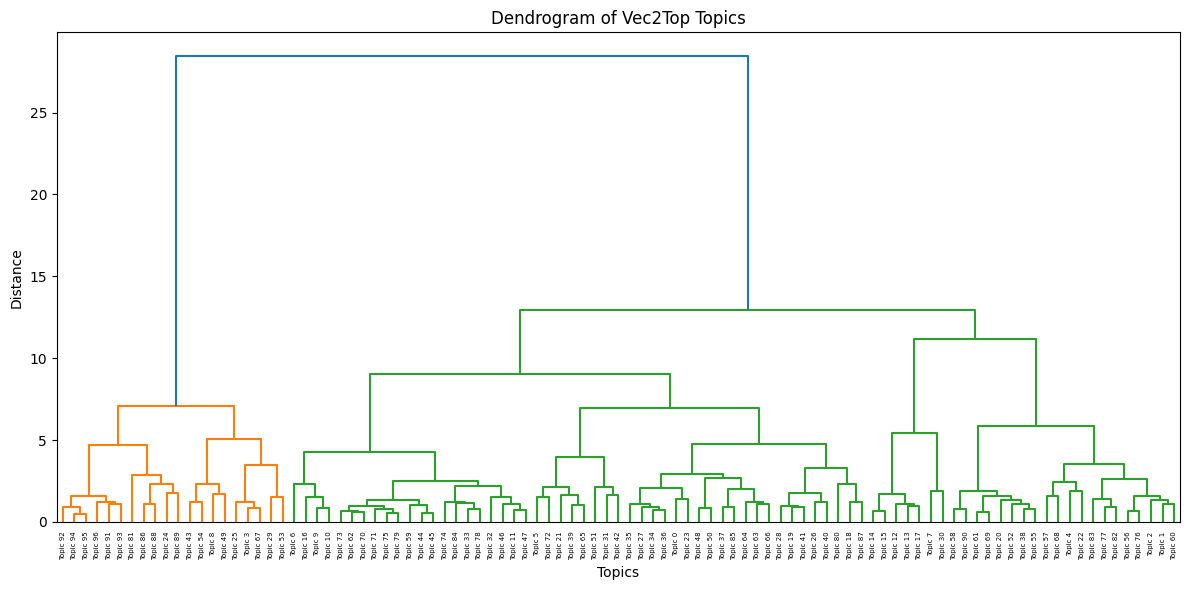

In [ ]:
# Optional: use document_topic_matrix if you'd rather visualize topics by their document composition
# topic_embeddings = model.document_topic_matrix.T  # shape: (num_topics, num_documents)

# Compute pairwise cosine distance matrix
distance_matrix = cosine_distances(topic_embeddings)

# Step 3: Perform hierarchical clustering
linkage_matrix = linkage(distance_matrix, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine

# Step 4: Plot the dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, labels=[f"Topic {i}" for i in range(len(topic_names))], leaf_rotation=90)
plt.title("Dendrogram of Vec2Top Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Dendrogram for BERTopic

In [ ]:
# Extract topic names and embeddings from the model
topic_names1 = model1.topic_names
topic_embeddings1 = topic_data1.topic_term_matrix  # shape: (num_topics, vocab_size)

topic_names1, topic_embeddings1

(['Genotype-phenotype association in cells expressing high levels of expression.',
  '"Caenorhabditis elegans Aging and Starvation: Effects on Membrane Metabolisms and Adult Worm Life',
  'Sea Ice Phenomena Modeling Issue: How Waves Affect Sea Ice Deformation',
  'Docking with QSAR models to identify the best inhibitors of molecular structures and their compounds.',
  'Pollen',
  'Platelet Function Time',
  'Headache-Related Migraine Treatment',
  'Vitamin B12 Deficiency',
  'suicide-indigenous-rates-self-die-cancer-people-men',
  'Eye Diseases',
  'Bone Implantation',
  'Dentistry for Young Children',
  'Moral Theory in Trust',
  'cardiac-synaptic-gaba-ion-channels',
  'Genetic Mutations',
  'Sensor-Based Network Algorithm for Improved Performance',
  'Neuroinflammation.',
  'Cancer Therapy',
  'Nanoparticles for Drug Delivery to Cells in a Vitro Setting for Brain Cancer',
  'Urbanization.',
  'Optical Properties of High-Quantum-Efficient Materials',
  'Mitochondrial Dose',
  'Genome 

In [ ]:
from scipy.spatial.distance import pdist

In [ ]:
len(topic_names1), len(topic_names)

(26, 97)

/tmp/ipython-input-41-3647701150.py:10: ClusterWarning:

The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix



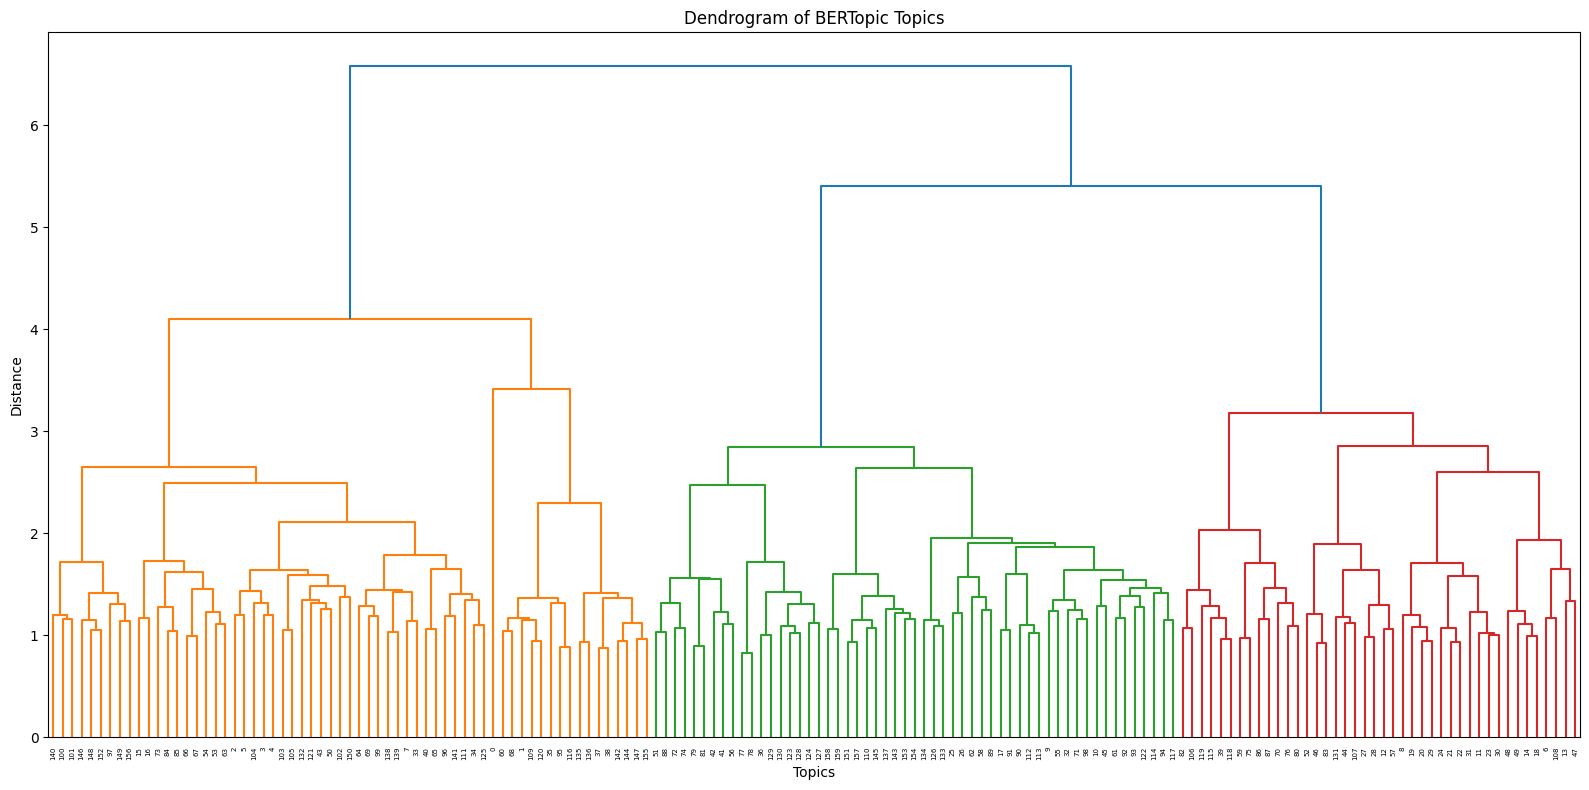

In [ ]:
# Optional: use document_topic_matrix if you'd rather visualize topics by their document composition
# topic_embeddings = model.document_topic_matrix.T  # shape: (num_topics, num_documents)

# Compute pairwise cosine distance matrix
distance_matrix1 = cosine_distances(topic_embeddings1)

lables = [f"Topic {i}" for i in range(len(topic_names1))]

# Perform hierarchical clustering
linkage_matrix1 = linkage(distance_matrix1, method='ward')  # 'ward' works better with Euclidean, use 'average' for cosine


# Plot the dendrogram
plt.figure(figsize=(16, 8))
dendrogram(linkage_matrix1, labels=None, leaf_rotation=90)
plt.title("Dendrogram of BERTopic Topics")
plt.xlabel("Topics")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

### Calculate and display standard deviation


In [ ]:
# Show embeddings matrix and Check the dimention of each eambeding
print(embeddings,"\n\n", embeddings.shape)

[[-0.06247491 -0.06421211 -0.04776807 ...  0.05779283 -0.00046217
  -0.0348533 ]
 [ 0.03635849 -0.05012973 -0.0077231  ... -0.00230364  0.01381705
  -0.08019841]
 [ 0.01247236  0.01453279 -0.01938152 ...  0.00787823  0.01995303
  -0.02415804]
 ...
 [-0.00543451 -0.08347747  0.03953594 ... -0.01684228 -0.10415071
   0.11270402]
 [-0.06943101 -0.0625765  -0.00057785 ...  0.00205806  0.01154448
  -0.04431521]
 [-0.07437815  0.00144461 -0.0106479  ... -0.01505966 -0.03949417
  -0.08860712]] 

 (10000, 384)


In [ ]:
# Calculate the standard deviation across all elements in the embeddings matrix
overall_std_dev = np.std(embeddings)
print(f"Overall Standard Deviation of Embeddings: {overall_std_dev:.4f}")


Overall Standard Deviation of Embeddings: 0.0510


In [ ]:
# Calculate the standard deviation for each dimension (column) of the embeddings
std_dev_per_dimension = np.std(embeddings, axis=0)
print("\nStandard Deviation per Embedding Dimension (first 10 dimensions):")
print(std_dev_per_dimension[:10]) # Print first 10 for brevity


Standard Deviation per Embedding Dimension (first 10 dimensions):
[0.04943018 0.05297992 0.04895246 0.05080314 0.05615833 0.0493866
 0.05057677 0.05560939 0.04570052 0.04802996]


In [ ]:
# descriptive statistics (mean and min/max) for std dev per dimension
print(f"\nMinimum Standard Deviation across dimensions: {np.min(std_dev_per_dimension):.4f}")
print(f"Maximum Standard Deviation across dimensions: {np.max(std_dev_per_dimension):.4f}")
print(f"Average Standard Deviation across dimensions: {np.mean(std_dev_per_dimension):.4f}")


Minimum Standard Deviation across dimensions: 0.0000
Maximum Standard Deviation across dimensions: 0.0643
Average Standard Deviation across dimensions: 0.0489


In [ ]:
# Define a small tolerance for floating-point comparison
# check if it's very close to 0. Standard deviation will almost never be exactly 0 due to floating point math.
tolerance = 1e-8

# Find the indices of dimensions where standard deviation is approximately zero
zero_std_dev_indices = np.where(std_dev_per_dimension < tolerance)[0]

if len(zero_std_dev_indices) > 0:
    print("Embedding dimensions with standard deviation approximately 0:")
    print(zero_std_dev_indices)
    print(f"Number of dimensions: {len(zero_std_dev_indices)}")
else:
    print("No embedding dimensions found with standard deviation approximately 0.")

# inspect the standard deviation values for these dimensions
print("\nStandard deviations with 0 value for these dimensions:")
print(std_dev_per_dimension[zero_std_dev_indices])

Embedding dimensions with standard deviation approximately 0:
[127 223 319]
Number of dimensions: 3

Standard deviations with 0 value for these dimensions:
[0.000000e+00 0.000000e+00 5.395018e-09]


In [ ]:
# Find the indices of dimensions where standard deviation is approximately zero
zero_std_dev_indices = np.where(std_dev_per_dimension < tolerance)[0]

if len(zero_std_dev_indices) > 0:
    print("Embedding dimensions with standard deviation approximately 0:")
    print(zero_std_dev_indices)
    print(f"Number of such dimensions: {len(zero_std_dev_indices)}")
    print("\n--- Exact elements in these dimensions across all rows ---")
    # Iterate through each identified dimension
    for dim_idx in zero_std_dev_indices:
        print(f"\nDimension Index: {dim_idx} (Standard Deviation: {std_dev_per_dimension[dim_idx]:.10f})")
        # Extract the entire column for this dimension
        elements_in_this_dimension = embeddings[:, dim_idx]
        print(f"Elements in Dimension {dim_idx} (first 10 and last 10, if many):")

        # If there are many elements, print a sample, otherwise print all
        if len(elements_in_this_dimension) > 20:
            print(elements_in_this_dimension[:384])
            # print("...")
            # print(elements_in_this_dimension[-10:])
        else:
            print(elements_in_this_dimension)
        print("-" * 50) # Separator for clarity
else:
    print("No embedding dimensions found with standard deviation approximately 0.")


Embedding dimensions with standard deviation approximately 0:
[127 223 319]
Number of such dimensions: 3

--- Exact elements in these dimensions across all rows ---

Dimension Index: 127 (Standard Deviation: 0.0000000000)
Elements in Dimension 127 (first 10 and last 10, if many):
[ 6.14512925e-33  4.80709048e-33  3.96042267e-33  5.83392630e-33
  3.28252353e-33  1.75171415e-33  2.36736977e-33  1.30512833e-33
  4.28340701e-33  4.96210732e-33  3.39182981e-33  1.25919285e-33
  3.82145463e-33  3.18606466e-33  4.89248720e-33  3.84813541e-33
 -3.71547936e-34  2.69799004e-33  2.24708529e-33  5.70722601e-33
  6.80620826e-34  3.15466207e-33  1.87632225e-33  3.19067517e-33
  8.32620722e-33  3.17499114e-33  1.42642125e-33  3.43605888e-33
  2.99417182e-33  2.41351527e-33  2.09418176e-33  4.03462869e-33
  7.39999040e-33  1.39787097e-33  3.63032365e-33  1.93520955e-33
  4.20550773e-33  4.22961235e-33  4.89151154e-33  3.43975030e-33
  5.70286346e-33  5.32251830e-33  5.06656653e-33  4.96294707e-33
  2.